In [ ]:
import pandas as pd
df = pd.read_csv("final2055.csv")
print("Data upload success!")
df.head()

Data upload success!


,page_link,page_id,query_time,post_id,post_created_time,post,comment_created_time,comment,sentiment
0,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782720089884147,2023-05-04T16:44:38+0000,🎀আমড়া দিয়ে মুরগি ভুনা🎀 ........রেসিপি...... উপ...,2023-05-05T05:02:13+0000,Morchi,N
1,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782719213217568,2023-05-04T16:42:54+0000,🎀সজনে ডাটায় লইট্যা শুটকি ভুনা🎀 .......রেসিপি.....,2023-05-06T18:45:46+0000,Onek mojar khabar,P
2,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782718369884319,2023-05-04T16:41:22+0000,🎀ডিমের সালাদ🎀 .......রেসিপি........ ডিমের সাল...,2023-05-05T03:16:48+0000,🥰🥰🥰❤️❤️❤️,P
3,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782718369884319,2023-05-04T16:41:22+0000,🎀ডিমের সালাদ🎀 .......রেসিপি........ ডিমের সাল...,2023-05-05T04:02:08+0000,👍😍,P
4,https://www.facebook.com/jhumurskitchen/,1.053349e+14,2023-05-07 9:10:28,105334900956006_782717199884436,2023-05-04T16:39:10+0000,🎀কাঁচা আমের টক ঝাল মিস্টি জুস/শরবত🎀 .....রেসিপ...,2023-05-05T04:37:15+0000,😋😋😋😋,P


In [ ]:
!pip install emoji

import pandas as pd
import emoji
import re

df = pd.read_csv("final2055.csv")
df = df[['comment', 'sentiment']].dropna()

def clean_text(text):
    if type(text) != str:
        return ""

    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s:]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaned_comment'] = df['comment'].apply(clean_text)

print("\n--- Data Cleaning and Emoji Processing Successful! ---\n")
display(df[['comment', 'cleaned_comment', 'sentiment']].head(10))

In [5]:
!pip install emoji
import pandas as pd
import emoji
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("final2055.csv")
df = df[['comment', 'sentiment']].dropna()

def clean_text(text):
    if type(text) != str:
        return ""

    text = text = emoji.replace_emoji(text, replace='')
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s:]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaned_comment'] = df['comment'].apply(clean_text)

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['cleaned_comment'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (Without Emoji): {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy (Without Emoji): 54.99%

Classification Report:
              precision    recall  f1-score   support

           N       0.66      0.28      0.39       104
         NEU       0.49      0.85      0.62       172
           P       0.77      0.37      0.50       135

    accuracy                           0.55       411
   macro avg       0.64      0.50      0.50       411
weighted avg       0.62      0.55      0.52       411



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print("Total number of comments:", len(df))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_comment'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Support Vector Machine (SVM)": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

print("--- Model Accuracy Results ---\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc * 100:.2f}%\n")

print("\n--- Detailed Classification Report (SVM) ---\n")
svm_model = models["Support Vector Machine (SVM)"]
print(classification_report(y_test, svm_model.predict(X_test)))

--- Model Accuracy Results ---

Support Vector Machine (SVM) Accuracy: 68.13%

Random Forest Accuracy: 65.45%

Logistic Regression Accuracy: 68.86%


--- Detailed Classification Report (SVM) ---

              precision    recall  f1-score   support

           N       0.64      0.50      0.56       104
         NEU       0.61      0.77      0.68       172
           P       0.84      0.71      0.77       135

    accuracy                           0.68       411
   macro avg       0.70      0.66      0.67       411
weighted avg       0.69      0.68      0.68       411



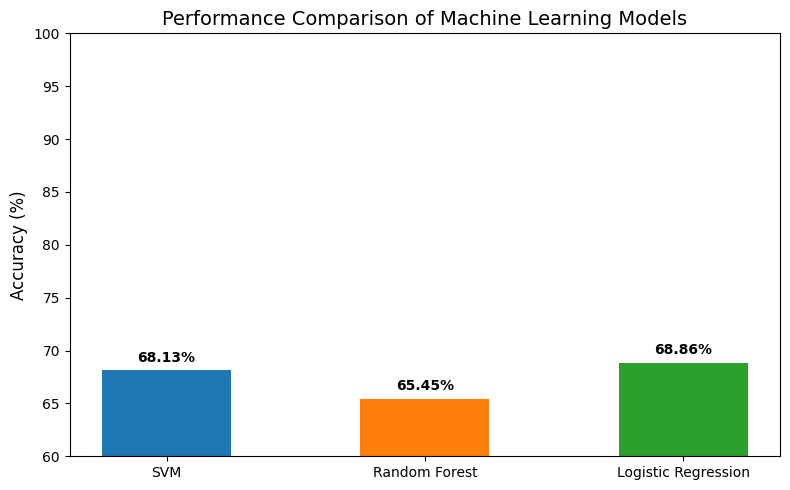

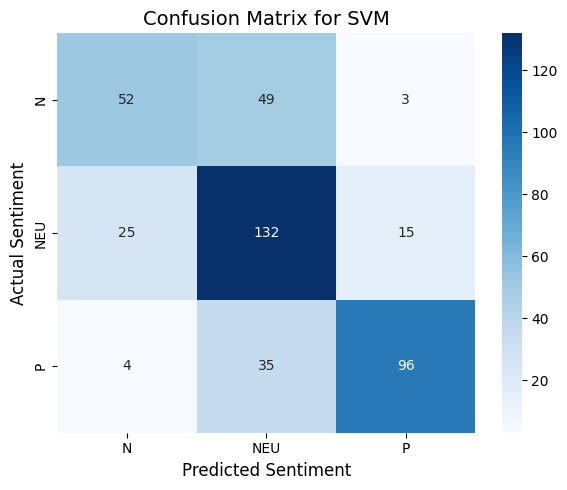

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_names = []
accuracies = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies.append(acc)
    if "SVM" in name:
        model_names.append("SVM")
    elif "Random" in name:
        model_names.append("Random Forest")
    else:
        model_names.append("Logistic Regression")

plt.figure(figsize=(8, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = plt.bar(model_names, accuracies, color=colors, width=0.5)
plt.ylim(60, 100)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Performance Comparison of Machine Learning Models', fontsize=14)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

svm_model = models["Support Vector Machine (SVM)"]
y_pred_svm = svm_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('Actual Sentiment', fontsize=12)
plt.title('Confusion Matrix for SVM', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:


import pandas as pd
df = pd.read_csv("final2055.csv")
df = df[['comment', 'sentiment']].dropna()
print("Total count of each sentiment:")
print(df['sentiment'].value_counts())

Total count of each sentiment:
sentiment
NEU    887
P      609
N      559
Name: count, dtype: int64
